Projet Final de Deep Learning : Classification des Maladies Pulmonaires à partir d'Images de Radiographies Thoraciques
Introduction :

Ce projet final du cours de deep learning se concentre sur un problème de santé réel en utilisant des techniques avancées d'apprentissage profond. L'objectif est de développer un modèle de classification capable de détecter diverses maladies pulmonaires à partir d'images de radiographies thoraciques, avec un impact clinique significatif.
Objectif :

Le principal objectif de ce projet est de créer un modèle de deep learning qui puisse classer les radiographies thoraciques en fonction de la présence de maladies pulmonaires, telles que la pneumonie.
Jeu de Données Suggéré :

Le jeu de données "Chest X-Ray Images (Pneumonia)" contient des milliers d'images de radiographies thoraciques annotées, indiquant la présence ou non de pneumonie.
Étapes du Projet :

    Collecte et Exploration des Données :
        Téléchargez le jeu de données "chest_xray" sur Kaggle.

    Prétraitement des Données :
        Redimensionnez et normalisez les images. Appliquez également des techniques d'augmentation des données pour enrichir le jeu de données et améliorer la généralisation du modèle.

    Construction du Modèle :
        Développez un modèle de deep learning adapté à la classification d'images, tel qu'un réseau neuronal convolutionnel (CNN).

    Entraînement du Modèle :
        Divisez les données en ensembles d'entraînement, de validation et de test. Entraînez le modèle tout en surveillant les métriques sur l'ensemble de validation.

    Évaluation et Analyse :
        Évaluez les performances du modèle sur l'ensemble de test en utilisant des métriques telles que l'accuracy, la précision, le rappel et la courbe ROC.

    Déploiement :
        Déployez le modèle avec Flask, en intégrant un formulaire HTML stylisé avec Bootstrap, permettant à l'utilisateur de télécharger une image de radiographie pour la classifier.

# Importation des modules

In [96]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, classification_report

from tensorflow.keras.utils import image_dataset_from_directory
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import TensorBoard
from tensorflow.keras.models import load_model
from tensorflow.keras.metrics import Precision, Recall, BinaryAccuracy
import tensorflow as tf

import warnings
warnings.filterwarnings('ignore')

# Chargement des images

Nous utilisons la fonction image_dataset_from_directory de keras.utils pour charger les images et les organiser en trois ensembles : entraînement, validation et test. Les images sont redimensionnées à une taille de 180x180 pixels, et sont traitées en lots de 64 images grâce à l'argument batch_size=64. Le paramètre label_mode='binary' est utilisé pour obtenir des étiquettes binaires (0 et 1), où 0 représente la classe NORMAL et 1 représente la classe PNEUMONIA. L'argument shuffle=True garantit que les images sont sélectionnées de manière aléatoire pour l'entraînement, ce qui permet d'améliorer la généralisation du modèle.

Ensuite, pour normaliser les images, nous divisons les pixels par 255, ce qui ramène les valeurs des pixels dans une échelle de 0 à 1.

In [70]:
train = image_dataset_from_directory('data/chest_xray/train'.encode('utf-8').decode('utf-8'), image_size = (180, 180), batch_size = 64, label_mode = 'binary', shuffle = True)
val = image_dataset_from_directory('data/chest_xray/val'.encode('utf-8').decode('utf-8'), image_size = (180, 180), batch_size = 64, label_mode = 'binary', shuffle = True)
test = image_dataset_from_directory('data/chest_xray/test'.encode('utf-8').decode('utf-8'), image_size = (180, 180), batch_size = 64, label_mode = 'binary', shuffle = True)

print(f'Classes dans les dataset : {train.class_names}')
class_names = train.class_names

train = train.map(lambda x, y : (x / 255, y))
val = val.map(lambda x, y : (x / 255, y))
test = test.map(lambda x, y : (x / 255, y))

Found 5216 files belonging to 2 classes.
Found 624 files belonging to 2 classes.
Found 16 files belonging to 2 classes.
Classes dans les dataset : ['NORMAL', 'PNEUMONIA']


Ainsi, le jeu de données contient 5216 images pour l'entraînement, 624 images pour la validation et 16 images pour le test.

Dimensions d'une image après redimensionnement : (180, 180, 3)


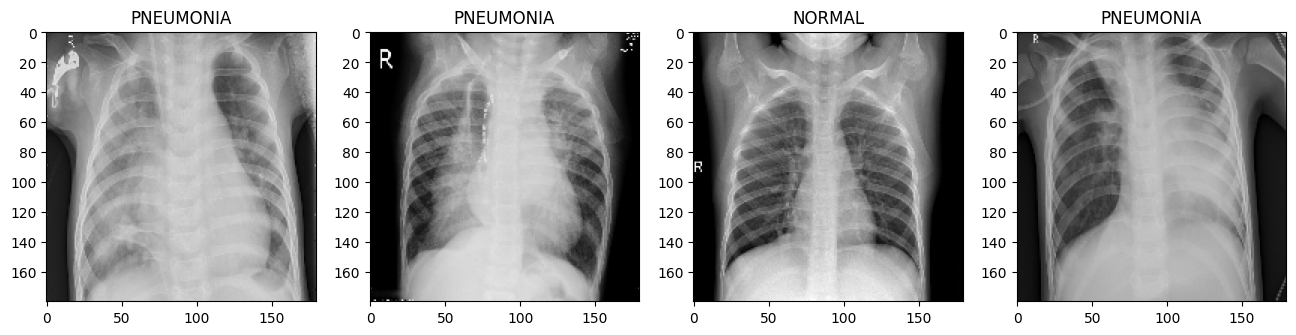

In [71]:
batch = train.as_numpy_iterator().next()
fig, ax = plt.subplots(ncols = 4, figsize = (16, 4))
for index, image in enumerate(batch[0][:4]) :
    ax[index].imshow(image, cmap = None)
    class_name = class_names[int(batch[1][index])]
    ax[index].title.set_text(class_name)
print(f"Dimensions d'une image après redimensionnement : {batch[0][0].shape}")

# Prétraitement des images

Étant donné que le nombre d'images de radiographies est limité, nous appliquerons une augmentation des données sur les ensembles d'entraînement et de validation. Cette augmentation comprendra des transformations telles que la rotation aléatoire des images, des décalages horizontaux et verticaux, des déformations par cisaillement, un zoom aléatoire, ainsi qu'un retournement horizontal aléatoire des images. Ces techniques permettront d'enrichir les jeux de données et d'améliorer la robustesse du modèle. Pour ce faire, nous utiliserons ImageDataGenerator de keras.preprocessing.

In [72]:
train_datagen = ImageDataGenerator(
    rescale = 1. / 255,
    rotation_range = 40,
    width_shift_range = 0.2,
    height_shift_range = 0.2,
    shear_range = 0.2,
    zoom_range = 0.2,
    horizontal_flip = True
)
train_generator = train_datagen.flow_from_directory(
    'data/chest_xray/train',
    target_size = (180, 180),
    batch_size = 64,
    class_mode = 'binary'
)

val_datagen = ImageDataGenerator(rescale = 1. / 255)
val_generator = val_datagen.flow_from_directory(
    'data/chest_xray/val',
    target_size = (180, 180),
    batch_size = 64,
    class_mode = 'binary'
)

Found 5216 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


Dimensions d'une image : (180, 180, 3)


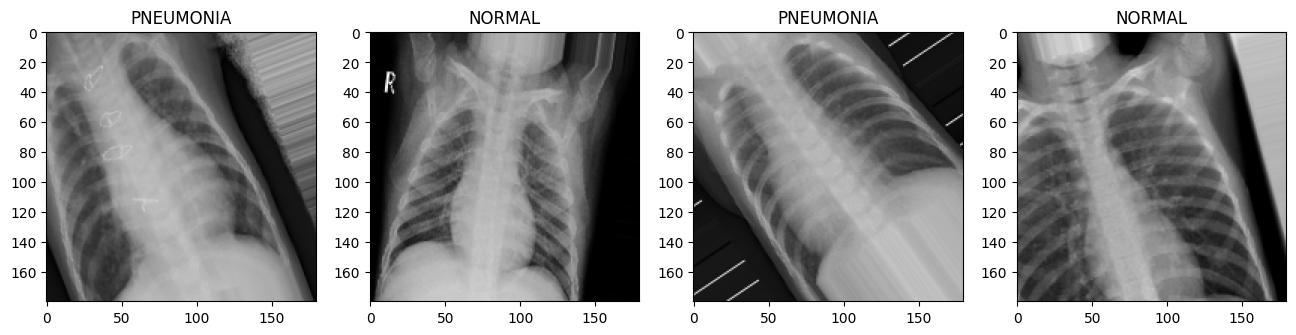

In [73]:
batch = train_generator.__next__()
fig, ax = plt.subplots(ncols = 4, figsize = (16, 4))
for index, image in enumerate(batch[0][:4]) :
    ax[index].imshow(image, cmap = None)
    class_name = class_names[int(batch[1][index])]
    ax[index].title.set_text(class_name)
print(f"Dimensions d'une image : {batch[0][0].shape}")

# Construction et entrainment du modèle

Nous utiliserons un modèle CNN, adapté à la classification d'images, qui comprend deux couches de convolution : la première avec 32 filtres et la deuxième avec 64 filtres, utilisant un noyau de taille 3x3 et la fonction d'activation ReLU. Ce modèle comporte également deux couches de pooling (2x2) pour réduire les dimensions spatiales, suivies d'une couche dense de 128 unités avec ReLU comme fonction d'activation. Enfin, une couche dense finale de 1 unité sera utilisée pour la classification binaire, avec la fonction d'activation Sigmoid. Le modèle sera ensuite compilé avec l'optimiseur Adam, la fonction de perte binary_crossentropy et la métrique accuracy.Nous utiliserons un modèle CNN, adapté à la classification d'images, qui comprend deux couches de convolution : la première avec 32 filtres et la deuxième avec 64 filtres, utilisant un noyau de taille 3x3 et la fonction d'activation ReLU. Ce modèle comporte également deux couches de pooling (2x2) pour réduire les dimensions spatiales, suivies d'une couche dense de 128 unités avec ReLU comme fonction d'activation. Enfin, une couche dense finale de 1 unité sera utilisée pour la classification binaire, avec la fonction d'activation Sigmoid. Le modèle sera ensuite compilé avec l'optimiseur Adam, la fonction de perte binary_crossentropy et la métrique accuracy.

Le modèle sera ensuite entraîné sur 20 époques pour améliorer sa robustesse et sa précision, en veillant à éviter le surapprentissage tout en optimisant les performances sur les données de test.

In [108]:
model = Sequential([
    Conv2D(32, (3, 3), strides = 1, activation = 'relu', input_shape = (180, 180, 3)),
    MaxPooling2D(2, 2),
    # Dropout(0.25),

    Conv2D(64, (3, 3), strides = 1, activation = 'relu'),
    MaxPooling2D(2, 2),
    # Dropout(0.25),

    Flatten(),
    Dense(128, activation = 'relu'),
    # Dropout(0.5),
    Dense(1, activation = 'sigmoid')
])

tensorboard_callback = TensorBoard(log_dir = "logs")

model.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])
model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_13 (MaxPooling2D) │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 118336)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │    15,147,136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,166,657 (57.86 MB)

 Trainable params: 15,166,657 (57.86 MB)

 Non-trainable params: 0 (0.00 B)

In [109]:
history = model.fit(train_generator, validation_data = val_generator, callbacks = [tensorboard_callback], epochs = 20)

Epoch 1/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 274s 3s/step - accuracy: 0.6936 - loss: 0.9515 - val_accuracy: 0.7308 - val_loss: 0.5414
Epoch 2/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 295s 3s/step - accuracy: 0.8334 - loss: 0.3730 - val_accuracy: 0.8189 - val_loss: 0.4118
Epoch 3/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 273s 3s/step - accuracy: 0.8581 - loss: 0.3197 - val_accuracy: 0.6795 - val_loss: 0.8311
Epoch 4/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 251s 3s/step - accuracy: 0.8409 - loss: 0.3441 - val_accuracy: 0.8381 - val_loss: 0.3640
Epoch 5/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 265s 3s/step - accuracy: 0.8704 - loss: 0.2954 - val_accuracy: 0.8381 - val_loss: 0.3517
Epoch 6/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 251s 3s/step - accuracy: 0.8668 - loss: 0.3011 - val_accuracy: 0.8510 - val_loss: 0.3570
Epoch 7/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 272s 3s/step - accuracy: 0.8815 - loss: 0.2825 - val_accuracy: 0.8574 - val_loss: 0.3787
Epoch 8/20
82/82 ━━━━━━━━━━━━━━━━━━━━ 284s 3s/step - accuracy: 0.8915 - loss: 0.2552 - val_accuracy: 0.8894 - v

# Evaluation du modèle

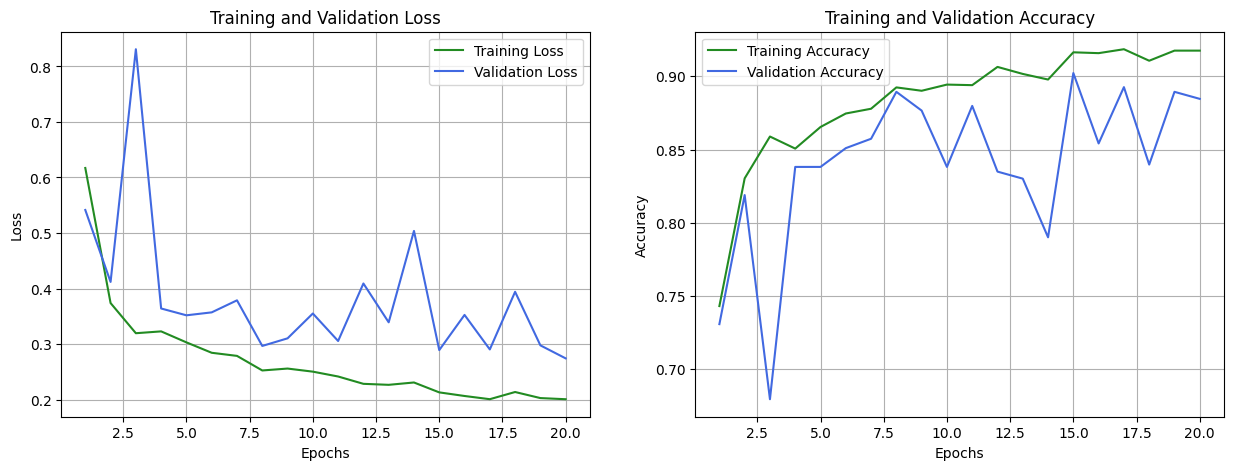

In [110]:
fig, ax = plt.subplots(ncols = 2, figsize = (15, 5))
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

epochs = range(1, len(train_loss) + 1)

ax[0].plot(epochs, train_loss, color = 'forestgreen', label = 'Training Loss')
ax[0].plot(epochs, val_loss, color = 'royalblue', label = 'Validation Loss')
ax[0].set_title('Training and Validation Loss')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].legend()
ax[0].grid(True)

ax[1].plot(epochs, train_acc, color = 'forestgreen', label = 'Training Accuracy')
ax[1].plot(epochs, val_acc, color = 'royalblue', label = 'Validation Accuracy')
ax[1].set_title('Training and Validation Accuracy')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy')
ax[1].legend()
ax[1].grid(True)

plt.show()

In [111]:
precision = Precision()
recall = Recall()
accuracy = BinaryAccuracy()

y_true = []
y_preds = []

for batch in test.as_numpy_iterator() :
    X, y = batch
    y_pred = model.predict(X)
    y_true.extend(y)
    y_preds.extend(y_pred)

    precision.update_state(y, y_pred)
    recall.update_state(y, y_pred)
    accuracy.update_state(y, y_pred)

y_true = np.array(y_true)
y_preds = np.array(y_preds)

print(f'Precision : {precision.result().numpy()}')
print(f'Recall : {recall.result().numpy()}')
print(f'Accuracy : {accuracy.result().numpy()}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 594ms/step
Precision : 0.8888888955116272
Recall : 1.0
Accuracy : 0.9375


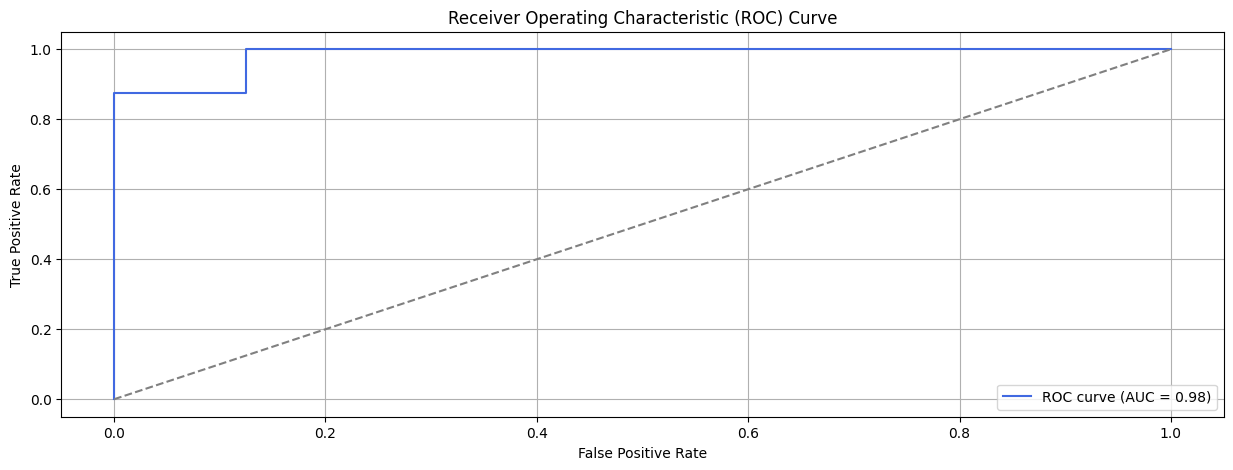

In [112]:
fpr, tpr, thresholds = roc_curve(y_true, y_preds)
roc_auc = auc(fpr, tpr)

plt.figure(figsize = (15, 5))
plt.plot(fpr, tpr, color = 'royalblue', label = f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color = 'gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc = "lower right")
plt.grid()
plt.show()

Résultats du Modèle

Après l'évaluation du modèle sur l'ensemble de test, les résultats obtenus sont les suivants :

    Précision (Precision) : 0.89
    Rappel (Recall) : 1.0
    Exactitude (Accuracy) : 93.75%
    AUC (Area Under the Curve) : 0.98

Interprétation des Résultats

    Précision (Precision) de 0.89 : Le modèle a correctement classé 89 % des images prédite comme étant de la classe PNEUMONIA. Cela signifie qu'il y a encore des faux positifs, mais globalement, le modèle est fiable pour identifier les cas de pneumonie.

    Rappel (Recall) de 1.0 : Le modèle a détecté tous les cas de pneumonie (aucun faux négatif). Cela est crucial pour un modèle médical, où il est plus important de détecter tous les cas positifs que de réduire les faux positifs.

    Exactitude (Accuracy) de 93.75% : Le modèle a correctement classé 93.75 % des images, ce qui indique une bonne performance générale. Cependant, l'exactitude peut être biaisée dans des jeux de données déséquilibrés, mais elle reste un bon indicateur dans ce contexte.

    AUC de 0.98 : L'Area Under the Curve est très élevée, montrant que le modèle a une excellente capacité à différencier les classes (NORMAL et PNEUMONIA) avec une probabilité très faible de confusion.

Conclusion

Le modèle CNN a montré des performances exceptionnelles avec une excellente capacité à détecter la pneumonie, comme en témoigne un rappel parfait (1.0) et une AUC de 0.98. Cependant, il existe encore un léger compromis en termes de précision (0.89), ce qui signifie qu'il y a quelques faux positifs. En fonction du cas d'utilisation, ces résultats peuvent être considérés comme très bons, surtout dans un contexte médical où il est souvent plus acceptable de classer un cas normal comme une pneumonie (faux positif) plutôt que de manquer un cas réel de pneumonie (faux négatif).

In [113]:
y_preds_binary = (y_preds > 0.5).astype(int)
print(classification_report(y_true, y_preds_binary))

              precision    recall  f1-score   support

         0.0       1.00      0.88      0.93         8
         1.0       0.89      1.00      0.94         8

    accuracy                           0.94        16
   macro avg       0.94      0.94      0.94        16
weighted avg       0.94      0.94      0.94        16



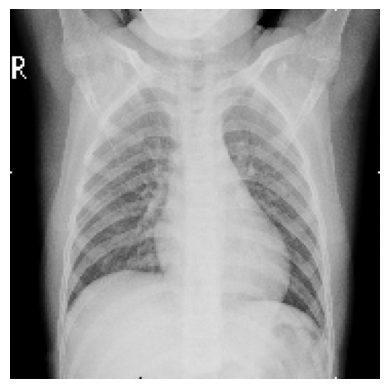

In [122]:
image_path = 'data/chest_xray/test/NORMAL/NORMAL2-IM-1427-0001.jpeg'
img_height = 180
img_width = 180

image = load_img(image_path, target_size = (img_height, img_width))
image_array = img_to_array(image)
image_array = np.expand_dims(image_array, axis = 0)
image_array = image_array / 255.0

image_to_display = np.squeeze(image_array, axis = 0)
plt.imshow(image_to_display.astype('float32'))
plt.axis('off')
plt.show()


In [123]:
predictions = model.predict(image_array)
if predictions[0] > 0.5 :
    print("Classe prédite : PNEUMONIA")
else :
    print("Classe prédite : NORMAL")
print(f"Probabilité de la classe PNEUMONIA : {predictions[0][0]:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
Classe prédite : NORMAL
Probabilité de la classe PNEUMONIA : 0.28


In [146]:
def predict_image(image_path) :
    image = load_img(image_path, target_size = (180, 180))
    image_array = img_to_array(image)
    image_array = np.expand_dims(image_array, axis = 0)
    image_array = image_array / 255.0

    predictions = model.predict(image_array, verbose = 0)
    if predictions[0] > 0.5 :
        print("Classe prédite : PNEUMONIA")
    else :
        print("Classe prédite : NORMAL")
    # print(f"Probabilité de la classe PNEUMONIA : {predictions[0][0]:.2f}")

In [148]:
test_path = 'data/chest_xray/test'
for image in glob.glob(os.path.join(test_path, 'NORMAL', '*')) :
    print(f'{image} prediction : ')
    predict_image(image)
    print('---------------------------------------------------------')

data/chest_xray/test\NORMAL\NORMAL2-IM-1427-0001.jpeg prediction : 
Classe prédite : NORMAL
---------------------------------------------------------
data/chest_xray/test\NORMAL\NORMAL2-IM-1430-0001.jpeg prediction : 
Classe prédite : NORMAL
---------------------------------------------------------
data/chest_xray/test\NORMAL\NORMAL2-IM-1431-0001.jpeg prediction : 
Classe prédite : NORMAL
---------------------------------------------------------
data/chest_xray/test\NORMAL\NORMAL2-IM-1436-0001.jpeg prediction : 
Classe prédite : NORMAL
---------------------------------------------------------
data/chest_xray/test\NORMAL\NORMAL2-IM-1437-0001.jpeg prediction : 
Classe prédite : NORMAL
---------------------------------------------------------
data/chest_xray/test\NORMAL\NORMAL2-IM-1438-0001.jpeg prediction : 
Classe prédite : PNEUMONIA
---------------------------------------------------------
data/chest_xray/test\NORMAL\NORMAL2-IM-1440-0001.jpeg prediction : 
Classe prédite : NORMAL
-----

In [149]:
test_path = 'data/chest_xray/test'
for image in glob.glob(os.path.join(test_path, 'PNEUMONIA', '*')) :
    print(f'{image} prediction : ')
    predict_image(image)
    print('---------------------------------------------------------')

data/chest_xray/test\PNEUMONIA\person1946_bacteria_4874.jpeg prediction : 
Classe prédite : PNEUMONIA
---------------------------------------------------------
data/chest_xray/test\PNEUMONIA\person1946_bacteria_4875.jpeg prediction : 
Classe prédite : PNEUMONIA
---------------------------------------------------------
data/chest_xray/test\PNEUMONIA\person1947_bacteria_4876.jpeg prediction : 
Classe prédite : PNEUMONIA
---------------------------------------------------------
data/chest_xray/test\PNEUMONIA\person1949_bacteria_4880.jpeg prediction : 
Classe prédite : PNEUMONIA
---------------------------------------------------------
data/chest_xray/test\PNEUMONIA\person1950_bacteria_4881.jpeg prediction : 
Classe prédite : PNEUMONIA
---------------------------------------------------------
data/chest_xray/test\PNEUMONIA\person1951_bacteria_4882.jpeg prediction : 
Classe prédite : PNEUMONIA
---------------------------------------------------------
data/chest_xray/test\PNEUMONIA\person195

# Sauvegarde du modèle

In [152]:
model.save('Deploiement/models/pneumonia-x-ray-detection.h5')